In [ ]:
!pip install transformers torch torchvision pillow

In [ ]:
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import requests

# Load pre-trained mod-el
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

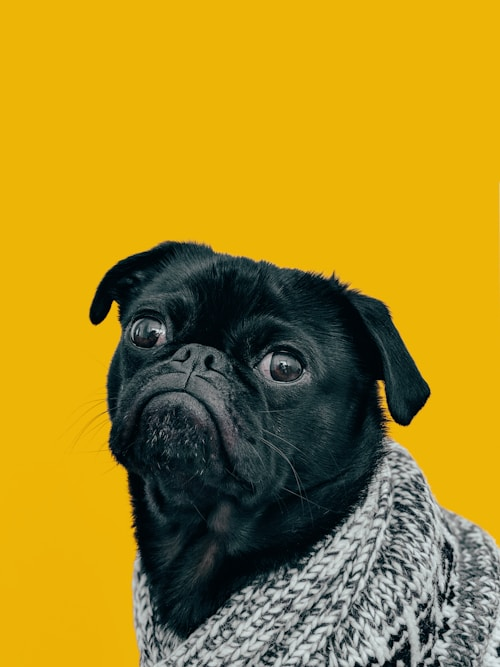

In [ ]:
url = "https://images.unsplash.com/photo-1517849845537-4d257902454a?w=500"

image = Image.open(requests.get(url, stream=True).raw)
image

In [ ]:
inputs = processor(images=image, return_tensors="pt")

outputs = model(**inputs)

logits = outputs.logits

predicted_class = logits.argmax(-1).item()

print("Predicted Class:")
print(model.config.id2label[predicted_class])

Predicted Class:
pug, pug-dog


In [ ]:
import torch

probabilities = torch.nn.functional.softmax(logits, dim=-1)

top5 = torch.topk(probabilities,5)

for score,index in zip(top5.values[0],top5.indices[0]):
    print(model.config.id2label[index.item()],":",round(score.item()*100,2),"%")

pug, pug-dog : 73.24 %
stole : 7.65 %
bull mastiff : 3.65 %
poncho : 1.64 %
French bulldog : 0.96 %


In [ ]:
#gemini image generation

In [ ]:
from google import genai

In [ ]:
from google.colab import userdata
GEMINI_API_KEY=userdata.get('geminikey3')

In [ ]:
client=genai.Client(api_key=GEMINI_API_KEY)

In [ ]:
from google.genai import types
from PIL import Image
from io import BytesIO

In [ ]:
prompt = """
A futuristic AI laboratory with humanoid robots,
holographic computers,
cinematic lighting,
photorealistic,
8K resolution.
"""

In [ ]:
for model in client.models.list():
    print(model.name)
    print(model.supported_actions if hasattr(model, "supported_actions") else "")
    print("-" * 40)

models/gemini-2.5-flash
['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
----------------------------------------
models/gemini-2.5-pro
['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
----------------------------------------
models/gemini-2.0-flash
['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
----------------------------------------
models/gemini-2.0-flash-001
['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
----------------------------------------
models/gemini-2.0-flash-lite-001
['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
----------------------------------------
models/gemini-2.0-flash-lite
['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
----------------------------------------
models/gemini-2.5-flash-preview-tts
['countTokens', 'generateContent']
-------------------------------

In [ ]:
for model in client.models.list():
    name = model.name.lower()
    if "image" in name or "imagen" in name:
        print(model.name)

models/gemini-2.5-flash-image
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/imagen-4.0-generate-001
models/imagen-4.0-ultra-generate-001
models/imagen-4.0-fast-generate-001


In [ ]:
response = client.models.generate_content(

    model="gemini-3.5-flash",

    contents=prompt,

    config=types.GenerateContentConfig(
        response_modalities=["TEXT","IMAGE"]
    )
)

In [ ]:
for part in response.candidates[0].content.parts:

    if getattr(part, "text", None):
        print("Text Response:")
        print(part.text)

    if getattr(part, "inline_data", None):
        image = Image.open(BytesIO(part.inline_data.data))
        display(image)

Text Response:
Here is a vivid description of your scene, followed by a highly optimized prompt you can use in AI image generators like Midjourney, DALL-E 3, or Stable Diffusion.

### Visual Description

The scene is set in a vast, subterranean AI research facility. The floor is made of polished dark obsidian, reflecting the array of lights from above like a still lake. 

In the center of the frame, an elegant humanoid robot stands with its back slightly turned, looking at a massive, floating holographic interface. The robot’s chassis is a mix of matte-black carbon fiber and polished chrome, with translucent panels on its limbs revealing gold circuitry and pulsing blue fiber-optic "veins." Its face is smooth and featureless, save for a soft, expressive glowing blue optical visor.

The holographic computer floats mid-air, casting a vibrant cyan and amber glow across the room. It displays complex, rotating 3D neural networks, stream-of-consciousness code, and anatomical wireframes of syn

In [ ]:
#gemini-2.5-flash-preview-image
response = client.models.generate_content(

    model="gemini-3.1-flash-image-preview",

    contents=prompt,

    config=types.GenerateContentConfig(
        response_modalities=["TEXT","IMAGE"]
    )
)

ClientError: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-3.1-flash-image\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-3.1-flash-image\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-3.1-flash-image\nPlease retry in 12.57571017s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {

In [ ]:
#image classification using pretrained models

Saving dog2.jpg to dog2.jpg


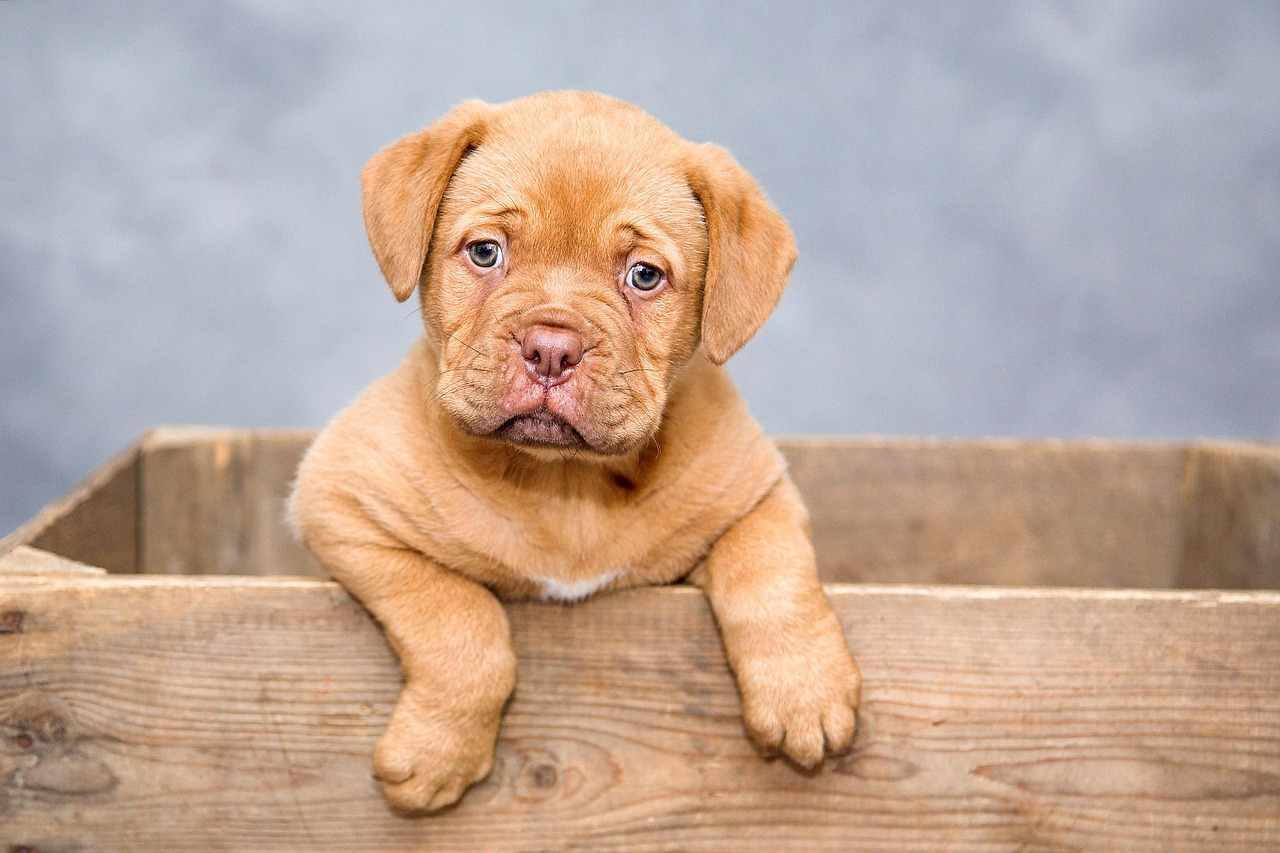

In [ ]:
from google.colab import files
from PIL import Image

uploaded = files.upload()

image = Image.open(list(uploaded.keys())[0]).convert("RGB")

image

In [ ]:
from transformers import CLIPProcessor
from transformers import CLIPModel

model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
)

processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [ ]:
labels = [
    "cat",
    "dog",
    "car",
    "bicycle",
    "horse"
]

inputs = processor(
    text=labels,
    images=image,
    return_tensors="pt",
    padding=True
)

outputs = model(**inputs)

logits = outputs.logits_per_image

probs = logits.softmax(dim=1)

print(probs)

tensor([[1.3525e-03, 9.9504e-01, 5.9797e-04, 1.1233e-03, 1.8857e-03]],
       grad_fn=<SoftmaxBackward0>)


In [ ]:
#image captioning

In [ ]:
from transformers import BlipProcessor
from transformers import BlipForConditionalGeneration

processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

inputs = processor(image, return_tensors="pt")

out = model.generate(**inputs)

caption = processor.decode(out[0], skip_special_tokens=True)

print(caption)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1625: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


a puppy puppy sitting in a wooden crate


In [ ]:
#music creation pretrained model

In [ ]:
!pip install -q transformers accelerate torch torchaudio sentencepiece

In [ ]:
!pip install -q huggingface_hub

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
from google.colab import userdata
HUGGINGFACE_API_KEY=userdata.get('hftoken')

In [ ]:
from huggingface_hub import login

login(token=HUGGINGFACE_API_KEY)

In [ ]:
import torch
import soundfile as sf
from diffusers import StableAudioPipeline

pipe = StableAudioPipeline.from_pretrained("stabilityai/stable-audio-open-1.0", torch_dtype=torch.float16)
pipe = pipe.to("cuda")

# define the prompts
prompt = "The sound of a hammer hitting a wooden surface."
negative_prompt = "Low quality."

# set the seed for generator
generator = torch.Generator("cuda").manual_seed(0)

# run the generation
audio = pipe(
    prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=200,
    audio_end_in_s=10.0,
    num_waveforms_per_prompt=3,
    generator=generator,
).audios

output = audio[0].T.float().cpu().numpy()
sf.write("hammer.wav", output, pipe.vae.sampling_rate)


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

ImportError: 
CosineDPMSolverMultistepScheduler requires the torchsde library but it was not found in your environment. You can install it with pip: `pip install torchsde`
